In [13]:
import numpy as np
import matplotlib.pyplot as plt


Fitted w0: 30.17 µm
Fitted z0: 23.73 mm
Fitted zR: 2.44 mm


Text(0.5, 1.0, 'Beam Waist Profile Fit')

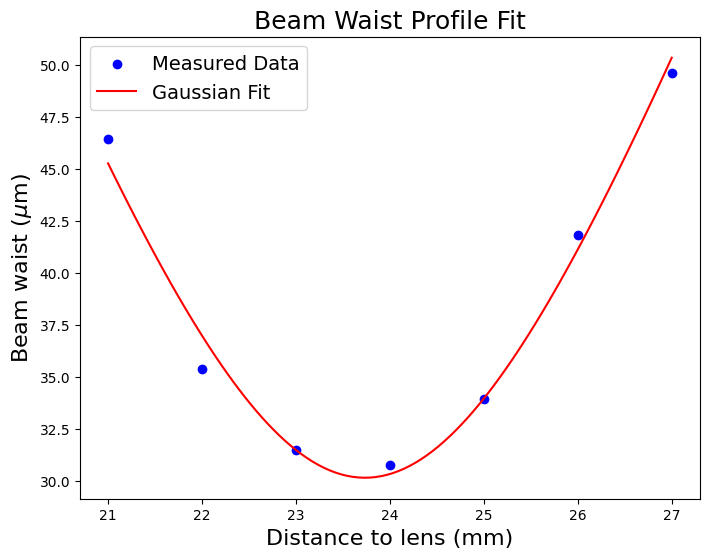

In [18]:
from scipy.optimize import curve_fit

filter_size = 6.4 *3
dist_to_detector = 7.5
distes = np.array([21,22,23,24,25,26,27]) *1e-3
waists = np.array([92.9, 70.8, 63, 61.6, 67.9, 83.7, 99.3])/2 *1e-6 #µm

# Define the Gaussian beam propagation equation
def beam_waist(z, w0, z0, zR):
    return w0 * np.sqrt(1 + ((z - z0) / zR)**2)

# Initial guesses: [w0, z0, zR]
p0 = [np.min(waists), distes[np.argmin(waists)], 1e-3]

# Fit the data using curve_fit
popt, pcov = curve_fit(beam_waist, distes, waists, p0=p0)
w0_fit, z0_fit, zR_fit = popt

print(f"Fitted w0: {w0_fit*1e6:.2f} µm")
print(f"Fitted z0: {z0_fit*1e3:.2f} mm")
print(f"Fitted zR: {zR_fit*1e3:.2f} mm")

# Generate points for the fitted curve
z_fit = np.linspace(distes.min(), distes.max(), 100)
w_fit = beam_waist(z_fit, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(distes*1e3, waists*1e6, color='blue', label='Measured Data')
ax.plot(z_fit*1e3, w_fit*1e6, color='red', label='Gaussian Fit')
ax.set_xlabel('Distance to lens (mm)', fontsize=16)
ax.set_ylabel('Beam waist ($\mu$m)', fontsize=16)
ax.legend(fontsize=14)
ax.set_title('Beam Waist Profile Fit', fontsize=18)


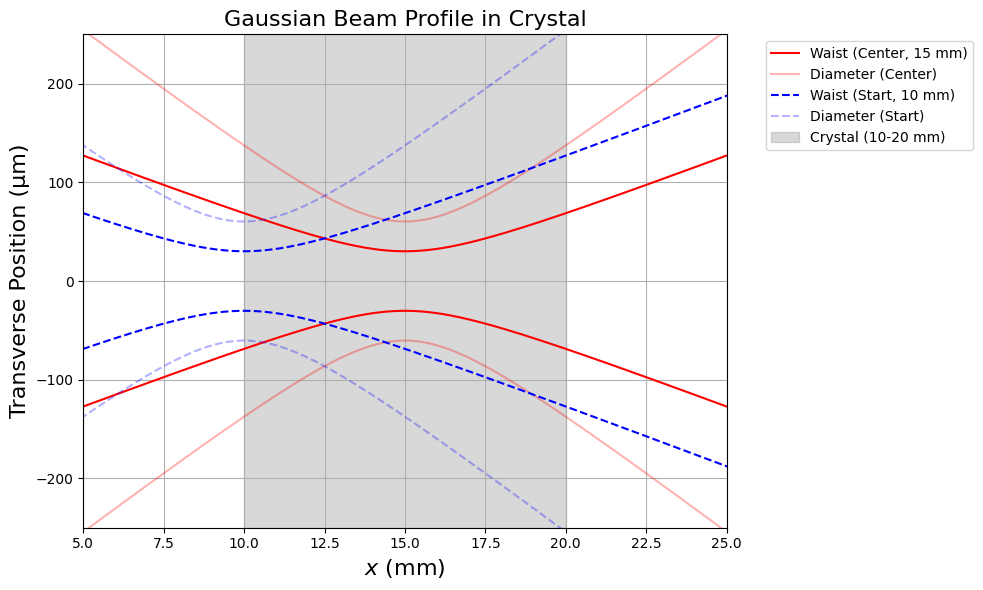

In [39]:
#Plot the fitted curve
w0 = w0_fit
zR = zR_fit

# Move waist to the middle of the crystal (15 mm)
z0_mid = 15e-3 
# Move waist to the start of the crystal (10 mm)
z0_start = 10e-3 

x = np.linspace(0, 30e-3, 1000)
plt.figure(figsize=(10, 6))

w_mid = beam_waist(x, w0, z0_mid, zR) * 1e6
w_start = beam_waist(x, w0, z0_start, zR) * 1e6

# Plot centered fit (mirrored waist)
plt.plot(x*1e3, w_mid, label='Waist (Center, 15 mm)', color='red')
plt.plot(x*1e3, -w_mid, color='red')
# Plot centered fit (mirrored diameter)
plt.plot(x*1e3, 2*w_mid, label='Diameter (Center)', color='red', alpha=0.3)
plt.plot(x*1e3, -2*w_mid, color='red', alpha=0.3)

# Plot start-shifted fit (mirrored waist)
plt.plot(x*1e3, w_start, label='Waist (Start, 10 mm)', color='blue', linestyle='--')
plt.plot(x*1e3, -w_start, color='blue', linestyle='--')
# Plot start-shifted fit (mirrored diameter)
plt.plot(x*1e3, 2*w_start, label='Diameter (Start)', color='blue', linestyle='--', alpha=0.3)
plt.plot(x*1e3, -2*w_start, color='blue', linestyle='--', alpha=0.3)

# Shade the crystal area from 10 mm to 20 mm
mask = (x >= 10e-3) & (x <= 20e-3)
plt.fill_between(x[mask]*1e3, -250, 250, color='gray', alpha=0.3, label='Crystal (10-20 mm)')

plt.xlim(5,25)
plt.ylim(-250, 250)
plt.xlabel('$x$ (mm)', fontsize=16)
plt.ylabel('Transverse Position (μm)', fontsize=16)
plt.title('Gaussian Beam Profile in Crystal', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

In [11]:
def P_in(V_out,R,T_gain):
    return 2*V_out/(R*T_gain)

R = 0.57
T = 2.38e5
V = 60e-3
P = P_in(V,R,T)
print(f'Estimated input power: {P*1e6:.2f} µW')

Estimated input power: 0.88 µW


In [17]:
epsilon_0 = 8.854187817e-12  # Vacuum permittivity (F/m)
c = 299792458  # Speed of light (m/s)
P=70e-3
p=16*np.pi**2*(15.4e-12)**2*10e-3/(epsilon_0*c*1.8**2*(1550e-9)**3) * P**2*
p

5.729908832024039e-05